# Project overview

RetentionLab is an end-to-end customer retention analytics project based on transactional e-commerce data. The project combines exploratory data analysis, customer segmentation, point-in-time feature engineering, and machine learning to identify customers who are likely to make no purchase in the next 60 days and prioritize them for retention campaigns.

# Business problem and goal

An e-commerce company has thousands of customers with different purchasing patterns. The company cannot give the same retention attention to every customer, so it needs a way to identify customers who may stop purchasing and prioritize limited retention resources.

The goal of RetentionLab is to predict which customers are likely to make no purchase during the next 60 days, understand the behavioral factors associated with this risk, and prioritize customers for retention campaigns.

# Dataset

In [14]:
%%time
import pandas as pd

df_1 = pd.read_excel(
    "OnlineRetail.xlsx",
    sheet_name="Year 2009-2010"
)

df_2 = pd.read_excel(
    "OnlineRetail.xlsx",
    sheet_name="Year 2010-2011"
)

df = pd.concat([df_1, df_2], ignore_index=True)

CPU times: total: 1min 28s
Wall time: 1min 28s


In [15]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [16]:
df.shape

(1067371, 8)

In [17]:
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


# Data Cleaning

In [18]:
# Creating dataframe with valid purchases
purchases = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (~df["Invoice"].astype(str).str.startswith("C"))
].copy()

In [19]:
purchases.isna().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236121
Country             0
dtype: int64

In [20]:
purchases.shape

(1041670, 8)

Customer IDs are missing for approximately 22.7% of purchase rows. These transactions are retained for transaction-level analysis but excluded from customer-level modeling because they cannot be reliably attributed to a customer.

In [21]:
# deleting these rows from customer-level modeling
customer_df = purchases.dropna(subset=["Customer ID"]).copy()

In [22]:
customer_df.shape

(805549, 8)

# Exploratory Data Analysis

In [23]:
# creating Revenue column
customer_df['Revenue'] = customer_df['Quantity']*customer_df['Price']

In [24]:
customer_df['Revenue'].describe()

count    805549.000000
mean         22.026505
std         224.041928
min           0.001000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

 We see that Revenue is right-skewed

In [12]:
customer_df.nlargest(
    10, "Revenue"
)[["Customer ID", "Invoice", "Quantity", "Price", "Revenue"]]

,Customer ID,Invoice,Quantity,Price,Revenue
1065882,16446.0,581483,80995,2.08,168469.60
587080,12346.0,541431,74215,1.04,77183.60
748132,15098.0,556444,60,649.50,38970.00
432176,15838.0,530715,9360,1.69,15818.40
135013,12918.0,502263,1,10953.50,10953.50
358639,14063.0,524159,1,10468.80,10468.80
74356,17949.0,496115,1,8985.60,8985.60
228042,18008.0,511465,3500,2.55,8925.00
698843,16029.0,551697,1,8142.75,8142.75
873786,17450.0,567423,1412,5.06,7144.72


Revenue is positive, the calculation is consistent, and the distribution has some extreme values 
that require investigation rather than automatic removal.

In [25]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# Customer-level analysis

In [26]:
# Customer-level features
customer_features = customer_df.groupby("Customer ID").agg(
    orders=("Invoice", "nunique"),
    revenue=("Revenue", "sum"),
    items=("Quantity", "sum"),
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max")
).reset_index()

# Calculate average order value at the invoice level
order_revenue = (
    customer_df
    .groupby(["Customer ID", "Invoice"], as_index=False)["Revenue"]
    .sum()
)

customer_aov = (
    order_revenue
    .groupby("Customer ID")["Revenue"]
    .mean()
)

customer_features["avg_order_value"] = (
    customer_features["Customer ID"]
    .map(customer_aov)
)

In [27]:
customer_features.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,avg_order_value
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,6463.038333
1,12347.0,8,5633.32,3286,2010-10-31 14:20:00,2011-12-07 15:52:00,704.165000
2,12348.0,5,2019.40,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,403.880000
3,12349.0,4,4428.69,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,1107.172500
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000


In [28]:
# A new column indicating how long each customer has been active
customer_features['lifetime_days'] = (
    customer_features['last_purchase']
    - customer_features['first_purchase']
).dt.days

In [29]:
customer_features.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,avg_order_value,lifetime_days
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,6463.038333,400
1,12347.0,8,5633.32,3286,2010-10-31 14:20:00,2011-12-07 15:52:00,704.165000,402
2,12348.0,5,2019.40,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,403.880000,362
3,12349.0,4,4428.69,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,1107.172500,570
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0


In [24]:
customer_features['lifetime_days'].describe()

count    5878.000000
mean      273.022457
std       258.807591
min         0.000000
25%         0.000000
50%       220.500000
75%       511.000000
max       738.000000
Name: lifetime_days, dtype: float64

Customer observed lifetime varies substantially, with some customers making purchases only once and others remaining active across much of the observation period.

In [30]:
# Creating recency column
analysis_date = customer_df["InvoiceDate"].max()

customer_features['recency'] = (
    analysis_date - customer_features['last_purchase']
).dt.days


In [31]:
customer_features.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,avg_order_value,lifetime_days,recency
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,6463.038333,400,325
1,12347.0,8,5633.32,3286,2010-10-31 14:20:00,2011-12-07 15:52:00,704.165000,402,1
2,12348.0,5,2019.40,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,403.880000,362,74
3,12349.0,4,4428.69,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,1107.172500,570,18
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0,309


In [19]:
customer_features['orders'].describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: orders, dtype: float64

Customer order frequency is strongly right-skewed, with most customers placing relatively few orders and a small group of highly frequent repeat customers.

In [20]:
customer_features['revenue'].describe()

count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: revenue, dtype: float64

Revenue is a highly positively skewed distribution (right-skewed)

In [21]:
customer_features["recency"].describe()

count    5878.000000
mean      200.331916
std       209.338707
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
max       738.000000
Name: recency, dtype: float64

Recency has a strongly right-skewed distribution with substantial dispersion. The mean (200 days) is considerably higher than the median (95 days), indicating that a relatively long upper tail is pulling the mean upward

In [32]:
print("30+ days:", (customer_features["recency"] > 30).sum())
print("60+ days:", (customer_features["recency"] > 60).sum())
print("90+ days:", (customer_features["recency"] > 90).sum())
print("180+ days:", (customer_features["recency"] > 180).sum())

30+ days: 4184
60+ days: 3456
90+ days: 2985
180+ days: 2398


We see that approximately 60% of customers made their last purchase more than 3 months ago, while 40% did it more than 6 months ago. In other words, a great number of customers made its last purchase several months ago

In [33]:
bins = [-1, 30, 60, 90, 180, 365, float("inf")]
labels = ["0-30", "31-60", "61-90", "91-180", "181-365", "365+"]

customer_features["recency_group"] = pd.cut(
    customer_features["recency"],
    bins=bins,
    labels=labels
)

print(customer_features["recency_group"].value_counts().sort_index())

recency_group
0-30       1694
31-60       728
61-90       471
91-180      587
181-365     800
365+       1598
Name: count, dtype: int64


Customer inactivity is highly concentrated in the long tail. A substantial share of customers have gone more than 90 days without purchasing, and approximately 27% have not purchased for more than one year. This suggests that customer reactivation may be an important business opportunity.

In [34]:
print("1 order:", (customer_features['orders']==1).sum())
print("2-3 orders:", customer_features['orders'].between(2, 3).sum())
print("4-7 orders:", customer_features['orders'].between(4, 7).sum())
print("8-20 orders:", customer_features['orders'].between(8, 20).sum())
print("21+ orders:", (customer_features['orders']>=21).sum())

1 order: 1623
2-3 orders: 1608
4-7 orders: 1348
8-20 orders: 1002
21+ orders: 297


Customer purchasing frequency is highly concentrated: 55% of customers made three or fewer orders, while only 5.1% made 21 or more orders. This indicates that a relatively small group of highly engaged repeat customers may contribute disproportionately to customer value.

In [35]:
customer_features.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,avg_order_value,lifetime_days,recency,recency_group
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,6463.038333,400,325,181-365
1,12347.0,8,5633.32,3286,2010-10-31 14:20:00,2011-12-07 15:52:00,704.165000,402,1,0-30
2,12348.0,5,2019.40,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,403.880000,362,74,61-90
3,12349.0,4,4428.69,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,1107.172500,570,18,0-30
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0,309,181-365


In [36]:
# comparing the revenue generated by each order-frequancy group
customer_features["order_group"] = pd.cut(
    customer_features["orders"],
    bins=[0, 1, 3, 7, 20, float("inf")],
    labels=["1", "2-3", "4-7", "8-20", "21+"]
)

revenue_by_group = customer_features.groupby(
    "order_group",
    observed=True
)["revenue"].agg(["sum", "mean", "median", "count"])

print(revenue_by_group)

                     sum          mean     median  count
order_group                                             
1             568173.832    350.076298    232.480   1623
2-3          1622596.023   1009.077129    640.945   1608
4-7          2497813.584   1852.977436   1420.845   1348
8-20         4966174.486   4956.261962   3778.060   1002
21+          8088671.253  27234.583343  12424.450    297


We conclude that only 297 customers (5.1%) are in the 21+ group, but they generated about £8.09M.

In [37]:
# calculating their share of total revenue
total_revenue = customer_features["revenue"].sum()

high_frequency_revenue = customer_features.loc[
    customer_features["orders"] >= 21,
    "revenue"
].sum()

print(high_frequency_revenue / total_revenue * 100)

45.58685455813191


We see that customers with 21+ orders represent only 5.1% of customers, but generate 45.59% of total revenue.

# RFM Segmentation

In [38]:
rfm = customer_features[
    ["Customer ID", "recency", "orders", "revenue"]
].copy()

rfm = rfm.rename(columns={
    "orders": "frequency",
    "revenue": "monetary"
})

rfm.head()

,Customer ID,recency,frequency,monetary
0,12346.0,325,12,77556.46
1,12347.0,1,8,5633.32
2,12348.0,74,5,2019.40
3,12349.0,18,4,4428.69
4,12350.0,309,1,334.40


In [39]:
# Creating rfm scores (recency, frequency, monetary)
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [40]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

In [41]:
rfm.head()

,Customer ID,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,12346.0,325,12,77556.46,2,5,5,12
1,12347.0,1,8,5633.32,5,4,5,14
2,12348.0,74,5,2019.40,3,4,4,11
3,12349.0,18,4,4428.69,5,3,5,13
4,12350.0,309,1,334.40,2,1,2,5


In [42]:
rfm.sort_values(
    "RFM_score",
    ascending=False
).head(20)

,Customer ID,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
4073,16458.0,2,30,5715.34,5,5,5,15
586,12935.0,1,15,4243.86,5,5,5,15
5004,17402.0,4,23,5096.18,5,5,5,15
5006,17404.0,3,23,47781.12,5,5,5,15
588,12937.0,14,9,3097.61,5,5,5,15
2729,15105.0,17,9,3094.91,5,5,5,15
1173,13534.0,1,35,7720.90,5,5,5,15
2717,15093.0,17,23,14326.11,5,5,5,15
5014,17412.0,2,16,4417.52,5,5,5,15
823,13174.0,15,12,9494.84,5,5,5,15


In [43]:
rfm["RFM_score"].value_counts().sort_index()

RFM_score
3     320
4     484
5     497
6     475
7     472
8     470
9     508
10    457
11    474
12    424
13    439
14    384
15    474
Name: count, dtype: int64

In [44]:
rfm[["R_score", "F_score", "M_score"]].value_counts().head(20)

R_score  F_score  M_score
5        5        5          474
1        1        1          320
4        5        5          249
1        2        1          173
3        4        4          167
2        1        1          162
1        1        2          149
4        4        4          147
1        2        2          137
5        4        4          134
3        5        5          132
2        2        2          122
                  1          116
         3        3          112
3        3        3          108
4        3        3          107
2        3        2           98
         1        2           96
3        1        1           94
5        5        4           93
Name: count, dtype: int64

In [45]:
# Recent, frequent, and high-value
rfm["segment"] = "Other"

rfm.loc[
    (rfm["R_score"] >= 4) &
    (rfm["F_score"] >= 4) &
    (rfm["M_score"] >= 4),
    "segment"
] = "Champions"

# High-value but inactive
rfm.loc[
    (rfm["R_score"] <= 2) &
    (rfm["M_score"] >= 4),
    "segment"
] = "High-value inactive"

#Recent but low-frequency
rfm.loc[
    (rfm["R_score"] >= 4) &
    (rfm["F_score"] <= 2),
    "segment"
] = "New / recent"

# Frequent but low-value
rfm.loc[
    (rfm["F_score"] >= 4) &
    (rfm["M_score"] <= 2),
    "segment"
] = "Frequent low-value"

In [46]:
rfm["segment"].value_counts()

segment
New / recent           2188
High-value inactive    2142
Other                  1407
Frequent low-value       81
Champions                60
Name: count, dtype: int64

In [47]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("Customer ID", "count"),
        revenue=("monetary", "sum"),
        avg_revenue=("monetary", "mean")
    )
    .sort_values("revenue", ascending=False)
)

segment_summary

,customers,revenue,avg_revenue
segment,,,
High-value inactive,2142,1.536240e+07,7171.986797
Other,1407,1.086874e+06,772.475851
New / recent,2188,1.009450e+06,461.357251
Champions,60,2.477618e+05,4129.363683
Frequent low-value,81,3.694845e+04,456.153704


In [48]:
segment_summary["revenue_share"] = (
    segment_summary["revenue"]
    / segment_summary["revenue"].sum()
    * 100
)

In [49]:
print(segment_summary)

                     customers       revenue  avg_revenue  revenue_share
segment                                                                 
High-value inactive       2142  1.536240e+07  7171.986797      86.580759
Other                     1407  1.086874e+06   772.475851       6.125499
New / recent              2188  1.009450e+06   461.357251       5.689146
Champions                   60  2.477618e+05  4129.363683       1.396358
Frequent low-value          81  3.694845e+04   456.153704       0.208237


86.6% of historical revenue is associated with customers classified as high-value inactive. This segmentation is descriptive and should not be interpreted as a prediction of future churn or recoverable revenue.

In [26]:
rfm[rfm["segment"] == "High-value inactive"]["recency"].describe()

count    2142.000000
mean       67.818861
std        91.267395
min         0.000000
25%         9.250000
50%        30.000000
75%        81.000000
max       409.000000
Name: recency, dtype: float64

In [27]:
rfm[rfm["segment"] == "High-value inactive"]["monetary"].describe()

count      2142.000000
mean       7171.986797
std       23812.103741
min        1249.010000
25%        1927.790000
50%        3126.570000
75%        5810.897500
max      608821.650000
Name: monetary, dtype: float64

In [32]:
rfm[rfm["segment"] == "High-value inactive"]["frequency"].describe()

count    2142.000000
mean       13.257703
std        19.527699
min         1.000000
25%         6.000000
50%         9.000000
75%        14.000000
max       398.000000
Name: frequency, dtype: float64

In [50]:
high_value_inactive = rfm[
    rfm["segment"] == "High-value inactive"
]

print(
    (high_value_inactive["recency"] > 365).sum()
)

print(
    (high_value_inactive["recency"] > 365).mean() * 100
)

57
2.661064425770308


In [25]:
high_value_inactive["recency"].value_counts(bins=5).sort_index()

(-0.41, 81.8]     1612
(81.8, 163.6]      259
(163.6, 245.4]     114
(245.4, 327.2]      75
(327.2, 409.0]      82
Name: count, dtype: int64

In [26]:
high_value_inactive["recency"].describe()

count    2142.000000
mean       67.818861
std        91.267395
min         0.000000
25%         9.250000
50%        30.000000
75%        81.000000
max       409.000000
Name: recency, dtype: float64

75% of this segment made their last purchase within roughly 82 days

# Target definition

In [51]:
orders = (
    customer_df
    .groupby(["Customer ID", "Invoice"], as_index=False)
    .agg(
        order_date=("InvoiceDate", "min"),
        order_revenue=("Revenue", "sum")
    )
)

In [52]:
orders.head()

,Customer ID,Invoice,order_date,order_revenue
0,12346.0,491725,2009-12-14 08:34:00,45.0
1,12346.0,491742,2009-12-14 11:00:00,22.5
2,12346.0,491744,2009-12-14 11:02:00,22.5
3,12346.0,492718,2009-12-18 10:47:00,22.5
4,12346.0,492722,2009-12-18 10:55:00,1.0


In [53]:
orders = orders.sort_values(
    ["Customer ID", "order_date"]
)

orders["days_since_previous_order"] = (
    orders.groupby("Customer ID")["order_date"]
    .diff()
    .dt.total_seconds() / (24 * 60 * 60)
)

In [54]:
order_gaps = orders["days_since_previous_order"].dropna()

In [55]:
order_gaps.describe()

count    31091.000000
mean        51.686656
std         75.788911
min          0.000000
25%          6.983333
50%         24.743056
75%         61.810417
max        714.152083
Name: days_since_previous_order, dtype: float64

So 60 days is actually a defensible starting point, because it's very close to the 75th percentile (61.8 days)

# Point-in-time feature engineering

In [56]:
gap_groups = pd.cut(
    order_gaps,
    bins=[-1, 7, 30, 60, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-60", "61-90",
            "91-180", "181-365", "365+"]
)

In [57]:
gap_groups.value_counts().sort_index()

days_since_previous_order
0-7        7850
8-30       9320
31-60      5969
61-90      2655
91-180     3322
181-365    1644
365+        331
Name: count, dtype: int64

We see that most repeat orders (74.4%) occur within 60 days, while a meaningful minority of customers have longer purchase cycles. This supports using 60 days as an initial churn-prediction window.

In [58]:
customer_df['InvoiceDate'].min()

Timestamp('2009-12-01 07:45:00')

In [59]:
customer_df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [60]:
prediction_date = pd.Timestamp("2011-09-01")

In [61]:
past = customer_df[
    customer_df["InvoiceDate"] <= prediction_date
].copy()

future = customer_df[
    (customer_df["InvoiceDate"] > prediction_date) &
    (customer_df["InvoiceDate"] <= prediction_date + pd.Timedelta(days=60))
].copy()

In [62]:
print("Past:", past["InvoiceDate"].min(), "→", past["InvoiceDate"].max())
print("Future:", future["InvoiceDate"].min(), "→", future["InvoiceDate"].max())

Past: 2009-12-01 07:45:00 → 2011-08-31 17:16:00
Future: 2011-09-01 08:25:00 → 2011-10-30 16:17:00


In [63]:
print("Past customers:", past["Customer ID"].nunique())
print("Future customers:", future["Customer ID"].nunique())

Past customers: 5249
Future customers: 2117


In [64]:
future_customers = future['Customer ID'].unique()

In [65]:
target = pd.DataFrame({
    "Customer ID": past["Customer ID"].unique()
})

target["churn_next_60d"] = (
    ~target["Customer ID"].isin(future_customers)
).astype(int)

In [66]:
target.head()

,Customer ID,churn_next_60d
0,13085.0,1
1,13078.0,0
2,15362.0,1
3,18102.0,0
4,12682.0,0


In [67]:
target["churn_next_60d"].value_counts(normalize=True) * 100

churn_next_60d
1    67.384264
0    32.615736
Name: proportion, dtype: float64

The target is fairly imbalanced

### 'past' dataframe grouping with Customer ID

In [68]:
features = (
    past.groupby("Customer ID")
    .agg(
        orders=("Invoice", "nunique"),
        revenue=("Revenue", "sum"),
        items=("Quantity", "sum"),
        first_purchase=("InvoiceDate", "min"),
        last_purchase=("InvoiceDate", "max"),
        unique_products=("StockCode", "nunique")
    )
    .reset_index()
)

In [69]:
features.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,unique_products
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,27
1,12347.0,6,4114.18,2418,2010-10-31 14:20:00,2011-08-02 08:48:00,107
2,12348.0,4,1709.40,2497,2010-09-27 14:59:00,2011-04-05 10:47:00,25
3,12349.0,3,2671.14,993,2010-04-29 13:20:00,2010-10-28 08:23:00,90
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,17


In [70]:
features["recency"] = (
    prediction_date - features["last_purchase"]
).dt.total_seconds() / (24 * 60 * 60)

features["tenure_days"] = (
    prediction_date - features["first_purchase"]
).dt.total_seconds() / (24 * 60 * 60)

features["avg_order_value"] = (
    features["revenue"] / features["orders"]
)

In [71]:
features.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,unique_products,recency,tenure_days,avg_order_value
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,27,225.582639,625.643056,6463.038333
1,12347.0,6,4114.18,2418,2010-10-31 14:20:00,2011-08-02 08:48:00,107,29.633333,304.402778,685.696667
2,12348.0,4,1709.40,2497,2010-09-27 14:59:00,2011-04-05 10:47:00,25,148.550694,338.375694,427.350000
3,12349.0,3,2671.14,993,2010-04-29 13:20:00,2010-10-28 08:23:00,90,307.650694,489.444444,890.380000
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,17,210.332639,210.332639,334.400000


In [72]:
# merging features table with the target created earlier
model_df = features.merge(
    target,
    on="Customer ID",
    how="inner"
)

In [73]:
model_df.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,unique_products,recency,tenure_days,avg_order_value,churn_next_60d
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,27,225.582639,625.643056,6463.038333,1
1,12347.0,6,4114.18,2418,2010-10-31 14:20:00,2011-08-02 08:48:00,107,29.633333,304.402778,685.696667,1
2,12348.0,4,1709.40,2497,2010-09-27 14:59:00,2011-04-05 10:47:00,25,148.550694,338.375694,427.350000,0
3,12349.0,3,2671.14,993,2010-04-29 13:20:00,2010-10-28 08:23:00,90,307.650694,489.444444,890.380000,1
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,17,210.332639,210.332639,334.400000,1


# Data leakage checks

In [74]:
features[["first_purchase", "last_purchase"]].max()

first_purchase   2011-08-31 14:35:00
last_purchase    2011-08-31 17:16:00
dtype: datetime64[ns]

In [75]:
(features["last_purchase"] > prediction_date).sum()

np.int64(0)

In [76]:
(features['first_purchase'] > prediction_date).sum()

np.int64(0)

In [77]:
past['InvoiceDate'].max()

Timestamp('2011-08-31 17:16:00')

In [78]:
future['InvoiceDate'].min()

Timestamp('2011-09-01 08:25:00')

In [79]:
future_counts = (
    future.groupby("Customer ID")["Invoice"]
    .nunique()
    .rename("future_orders")
)

In [80]:
check = model_df[["Customer ID", "churn_next_60d"]].merge(
    future_counts,
    on="Customer ID",
    how="left"
)

In [81]:
check["future_orders"] = check["future_orders"].fillna(0)
check.groupby("churn_next_60d")["future_orders"].describe()

,count,mean,std,min,25%,50%,75%,max
churn_next_60d,,,,,,,,
0,1712.0,1.796729,2.166271,1.0,1.0,1.0,2.0,51.0
1,3537.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [82]:
print("Future last_purchase:",
      (features["last_purchase"] > prediction_date).sum())

print("Future first_purchase:",
      (features["first_purchase"] > prediction_date).sum())

Future last_purchase: 0
Future first_purchase: 0


In [83]:
print("Past ends:", past["InvoiceDate"].max())
print("Future starts:", future["InvoiceDate"].min())

Past ends: 2011-08-31 17:16:00
Future starts: 2011-09-01 08:25:00


The first point-in-time dataset is leakage-free with respect to the prediction date and target construction.

# Train / Validation / Test Split

In [84]:
# Explicitting model features

feature_cols = [
    "orders",
    "revenue",
    "items",
    "unique_products",
    "recency",
    "tenure_days",
    "avg_order_value"
]

X = model_df[feature_cols]
y = model_df["churn_next_60d"]

In [85]:
X.head()

,orders,revenue,items,unique_products,recency,tenure_days,avg_order_value
0,12,77556.46,74285,27,225.582639,625.643056,6463.038333
1,6,4114.18,2418,107,29.633333,304.402778,685.696667
2,4,1709.40,2497,25,148.550694,338.375694,427.350000
3,3,2671.14,993,90,307.650694,489.444444,890.380000
4,1,334.40,197,17,210.332639,210.332639,334.400000


In [86]:
# monthly snapshots

prediction_dates = pd.date_range(
    start="2010-06-01",
    end="2011-09-01",
    freq="MS"
)

prediction_dates

DatetimeIndex(['2010-06-01', '2010-07-01', '2010-08-01', '2010-09-01',
               '2010-10-01', '2010-11-01', '2010-12-01', '2011-01-01',
               '2011-02-01', '2011-03-01', '2011-04-01', '2011-05-01',
               '2011-06-01', '2011-07-01', '2011-08-01', '2011-09-01'],
              dtype='datetime64[ns]', freq='MS')

# Baseline model

In [87]:
def create_snapshot(df, prediction_date, window_days=60):

    # -------------------------
    # 1. Split past and future
    # -------------------------
    future_date = prediction_date + pd.Timedelta(days=window_days)

    past = df[
        df["InvoiceDate"] <= prediction_date
    ].copy()

    future = df[
        (df["InvoiceDate"] > prediction_date) &
        (df["InvoiceDate"] <= future_date)
    ].copy()

    # -------------------------
    # 2. Create customer features
    # -------------------------
    features = (
        past.groupby("Customer ID")
        .agg(
            orders=("Invoice", "nunique"),
            revenue=("Revenue", "sum"),
            items=("Quantity", "sum"),
            first_purchase=("InvoiceDate", "min"),
            last_purchase=("InvoiceDate", "max"),
            unique_products=("StockCode", "nunique")
        )
        .reset_index()
    )

    # -------------------------
    # 3. Time-based features
    # -------------------------
    features["recency"] = (
        prediction_date - features["last_purchase"]
    ).dt.total_seconds() / (24 * 60 * 60)

    features["tenure_days"] = (
        prediction_date - features["first_purchase"]
    ).dt.total_seconds() / (24 * 60 * 60)

    features["avg_order_value"] = (
        features["revenue"] / features["orders"]
    )

    # -------------------------
    # 4. Create target
    # -------------------------
    future_customers = future["Customer ID"].unique()

    features["churn_next_60d"] = (
        ~features["Customer ID"].isin(future_customers)
    ).astype(int)

    # -------------------------
    # 5. Store prediction date
    # -------------------------
    features["prediction_date"] = prediction_date

    return features

In [88]:
snapshot_test = create_snapshot(
    customer_df,
    pd.Timestamp("2011-09-01")
)

In [89]:
snapshot_test.shape

(5249, 12)

In [90]:
snapshot_test.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,unique_products,recency,tenure_days,avg_order_value,churn_next_60d,prediction_date
0,12346.0,12,77556.46,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,27,225.582639,625.643056,6463.038333,1,2011-09-01
1,12347.0,6,4114.18,2418,2010-10-31 14:20:00,2011-08-02 08:48:00,107,29.633333,304.402778,685.696667,1,2011-09-01
2,12348.0,4,1709.40,2497,2010-09-27 14:59:00,2011-04-05 10:47:00,25,148.550694,338.375694,427.350000,0,2011-09-01
3,12349.0,3,2671.14,993,2010-04-29 13:20:00,2010-10-28 08:23:00,90,307.650694,489.444444,890.380000,1,2011-09-01
4,12350.0,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,17,210.332639,210.332639,334.400000,1,2011-09-01


In [91]:
snapshot_test['churn_next_60d'].value_counts(normalize=True) * 100

churn_next_60d
1    67.384264
0    32.615736
Name: proportion, dtype: float64

In [92]:
snapshot_test['churn_next_60d'].value_counts()

churn_next_60d
1    3537
0    1712
Name: count, dtype: int64

In [93]:
# creating 16 snapshots
snapshots = []

for date in prediction_dates:
    snapshot = create_snapshot(
        customer_df,
        date
    )
    snapshots.append(snapshot)

model_data = pd.concat(
    snapshots,
    ignore_index=True
)

In [94]:
model_data.shape

(67123, 12)

In [95]:
model_data.head()

,Customer ID,orders,revenue,items,first_purchase,last_purchase,unique_products,recency,tenure_days,avg_order_value,churn_next_60d,prediction_date
0,12346.0,10,230.55,51,2009-12-14 08:34:00,2010-03-02 13:08:00,7,90.452778,168.643056,23.0550,0,2010-06-01
1,12349.0,2,1268.52,474,2010-04-29 13:20:00,2010-05-18 09:57:00,47,13.585417,32.444444,634.2600,1,2010-06-01
2,12355.0,1,488.21,303,2010-05-21 11:59:00,2010-05-21 11:59:00,22,10.500694,10.500694,488.2100,1,2010-06-01
3,12358.0,1,1429.83,309,2009-12-08 07:59:00,2009-12-08 07:59:00,17,174.667361,174.667361,1429.8300,0,2010-06-01
4,12359.0,4,1522.23,777,2009-12-05 13:32:00,2010-03-23 08:55:00,65,69.628472,177.436111,380.5575,0,2010-06-01


In [96]:
model_data['prediction_date'].value_counts().sort_index()

prediction_date
2010-06-01    2703
2010-07-01    2973
2010-08-01    3159
2010-09-01    3321
2010-10-01    3564
2010-11-01    3941
2010-12-01    4266
2011-01-01    4342
2011-02-01    4413
2011-03-01    4537
2011-04-01    4716
2011-05-01    4822
2011-06-01    4933
2011-07-01    5041
2011-08-01    5143
2011-09-01    5249
Name: count, dtype: int64

In [97]:
model_data.isna().sum()

Customer ID        0
orders             0
revenue            0
items              0
first_purchase     0
last_purchase      0
unique_products    0
recency            0
tenure_days        0
avg_order_value    0
churn_next_60d     0
prediction_date    0
dtype: int64

In [98]:
model_data.duplicated(
    subset=['Customer ID', 'prediction_date']
).sum()

np.int64(0)

In [99]:
model_data.groupby('prediction_date')['churn_next_60d'].agg(
    ['count', 'mean']
)

,count,mean
prediction_date,,
2010-06-01,2703,0.585276
2010-07-01,2973,0.620922
2010-08-01,3159,0.598924
2010-09-01,3321,0.538392
2010-10-01,3564,0.515432
2010-11-01,3941,0.602385
2010-12-01,4266,0.734412
2011-01-01,4342,0.755412
2011-02-01,4413,0.737140


In [100]:
churn_by_date = (
    model_data.groupby("prediction_date")["churn_next_60d"]
    .agg(["count", "mean"])
)

churn_by_date["churn_rate"] = churn_by_date["mean"] * 100

churn_by_date

,count,mean,churn_rate
prediction_date,,,
2010-06-01,2703,0.585276,58.527562
2010-07-01,2973,0.620922,62.092163
2010-08-01,3159,0.598924,59.892371
2010-09-01,3321,0.538392,53.839205
2010-10-01,3564,0.515432,51.543210
2010-11-01,3941,0.602385,60.238518
2010-12-01,4266,0.734412,73.441163
2011-01-01,4342,0.755412,75.541225
2011-02-01,4413,0.737140,73.714027


In [101]:
model_data[
    [
        "orders",
        "revenue",
        "items",
        "unique_products",
        "recency",
        "tenure_days",
        "avg_order_value"
    ]
].describe()

,orders,revenue,items,unique_products,recency,tenure_days,avg_order_value
count,67123.000000,67123.000000,67123.000000,67123.000000,67123.000000,67123.000000,67123.000000
mean,4.609419,2163.974502,1350.260015,63.940065,132.488730,281.079638,381.846098
std,8.845503,9737.533361,6908.532894,88.897805,127.092777,161.076301,519.602898
min,1.000000,1.300000,1.000000,1.000000,0.161111,0.161111,1.300000
25%,1.000000,304.800000,152.000000,16.000000,32.351736,153.504167,179.885500
50%,2.000000,695.660000,382.000000,37.000000,90.456944,268.342361,290.593333
75%,5.000000,1744.850000,990.000000,78.000000,198.562847,403.394444,426.240000
max,303.000000,479701.580000,297009.000000,2168.000000,638.586806,638.677083,14844.766667


In [102]:
print("orders <= 0:", (model_data["orders"] <= 0).sum())
print("revenue <= 0:", (model_data["revenue"] <= 0).sum())
print("items <= 0:", (model_data["items"] <= 0).sum())
print("recency < 0:", (model_data["recency"] < 0).sum())
print("tenure_days < 0:", (model_data["tenure_days"] < 0).sum())
print("AOV <= 0:", (model_data["avg_order_value"] <= 0).sum())

orders <= 0: 0
revenue <= 0: 0
items <= 0: 0
recency < 0: 0
tenure_days < 0: 0
AOV <= 0: 0


In [103]:
train = model_data[
    model_data['prediction_date'] < '2011-06-01'
].copy()

test = model_data[
    model_data['prediction_date'] >= '2011-06-01'
].copy()

In [104]:
print('Train shape', train.shape)
print('Test shape', test.shape)

Train shape (46757, 12)
Test shape (20366, 12)


In [105]:
print(
    "Train dates:",
    train["prediction_date"].min(),
    "→",
    train["prediction_date"].max()
)

print(
    "Test dates:",
    test["prediction_date"].min(),
    "→",
    test["prediction_date"].max()
)

Train dates: 2010-06-01 00:00:00 → 2011-05-01 00:00:00
Test dates: 2011-06-01 00:00:00 → 2011-09-01 00:00:00


In [106]:
feature_cols = [
    "orders",
    "revenue",
    "items",
    "unique_products",
    "recency",
    "tenure_days",
    "avg_order_value"
]

X_train = train[feature_cols]
y_train = train["churn_next_60d"]

X_test = test[feature_cols]
y_test = test["churn_next_60d"]

In [107]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (46757, 7)
y_train: (46757,)
X_test: (20366, 7)
y_test: (20366,)


# Baseline model

### Dummy baseline

In [108]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

churn_next_60d
1    31102
0    15655
Name: count, dtype: int64
churn_next_60d
1    66.518382
0    33.481618
Name: proportion, dtype: float64


In [109]:
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

churn_next_60d
1    14573
0     5793
Name: count, dtype: int64
churn_next_60d
1    71.555534
0    28.444466
Name: proportion, dtype: float64


In [110]:
%%time
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(
strategy = 'most_frequent'
)

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

print('Dummy accuracy:', dummy_accuracy)

Dummy accuracy: 0.7155553373269175
CPU times: total: 797 ms
Wall time: 1.31 s


### Logistic regression

In [111]:
%%time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

print("\nClassification report:")
print(classification_report(y_test, y_pred_logreg))

y_prob_logreg = logreg.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_logreg)
)

Accuracy: 0.7821859962682903

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.44      0.54      5793
           1       0.81      0.92      0.86     14573

    accuracy                           0.78     20366
   macro avg       0.74      0.68      0.70     20366
weighted avg       0.77      0.78      0.77     20366

ROC-AUC: 0.8039761463768381
CPU times: total: 453 ms
Wall time: 186 ms


Logistic Regression achieved 78.2% accuracy and 0.804 ROC-AUC on the chronological holdout set, compared with a 71.6% majority-class baseline.

In [112]:
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logreg.named_steps["model"].coef_[0]
})

coefficients["abs_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients.sort_values(
    "abs_coefficient",
    ascending=False
)

,feature,coefficient,abs_coefficient
0,orders,-1.210719,1.210719
4,recency,0.532108,0.532108
3,unique_products,-0.193468,0.193468
5,tenure_days,0.080172,0.080172
2,items,0.065925,0.065925
6,avg_order_value,-0.051392,0.051392
1,revenue,-0.007069,0.007069


### Random forest

In [113]:
%%time
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

Accuracy: 0.7943140528331533

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.47      0.56      5793
           1       0.81      0.92      0.87     14573

    accuracy                           0.79     20366
   macro avg       0.76      0.70      0.71     20366
weighted avg       0.78      0.79      0.78     20366

ROC-AUC: 0.8135002019452677
CPU times: total: 25.7 s
Wall time: 2.59 s


Random Forest achieved ROC-AUC of 0.814 and 92% recall for customers who made no purchase in the following 60 days, compared with a 71.6% majority-class baseline.

### DataFrame with additional features (orders_30d, revenue_30d etc)

In [114]:
def create_snapshot(df, prediction_date, window_days=60):

    future_date = prediction_date + pd.Timedelta(days=window_days)

    # Past data
    past = df[df["InvoiceDate"] <= prediction_date].copy()

    # Future data for target
    future = df[
        (df["InvoiceDate"] > prediction_date) &
        (df["InvoiceDate"] <= future_date)
    ].copy()

    # -------------------------
    # Lifetime features
    # -------------------------

    features = (
        past.groupby("Customer ID")
        .agg(
            orders=("Invoice", "nunique"),
            revenue=("Revenue", "sum"),
            items=("Quantity", "sum"),
            first_purchase=("InvoiceDate", "min"),
            last_purchase=("InvoiceDate", "max"),
            unique_products=("StockCode", "nunique")
        )
        .reset_index()
    )

    features["recency"] = (
        prediction_date - features["last_purchase"]
    ).dt.total_seconds() / 86400

    features["tenure_days"] = (
        prediction_date - features["first_purchase"]
    ).dt.total_seconds() / 86400

    features["avg_order_value"] = (
        features["revenue"] / features["orders"]
    )

    # -------------------------
    # Recent 30-day behavior
    # -------------------------

    start_30d = prediction_date - pd.Timedelta(days=30)

    recent_30d = past[
        past["InvoiceDate"] > start_30d
    ]

    recent_30_features = (
        recent_30d.groupby("Customer ID")
        .agg(
            orders_30d=("Invoice", "nunique"),
            revenue_30d=("Revenue", "sum"),
            items_30d=("Quantity", "sum")
        )
    )

    # -------------------------
    # Recent 90-day behavior
    # -------------------------

    start_90d = prediction_date - pd.Timedelta(days=90)

    recent_90d = past[
        past["InvoiceDate"] > start_90d
    ]

    recent_90_features = (
        recent_90d.groupby("Customer ID")
        .agg(
            orders_90d=("Invoice", "nunique"),
            revenue_90d=("Revenue", "sum"),
            items_90d=("Quantity", "sum")
        )
    )

    # -------------------------
    # Merge recent features
    # -------------------------

    features = features.merge(
        recent_30_features,
        on="Customer ID",
        how="left"
    )

    features = features.merge(
        recent_90_features,
        on="Customer ID",
        how="left"
    )

    # Customers with no recent activity get zero
    recent_columns = [
        "orders_30d",
        "revenue_30d",
        "items_30d",
        "orders_90d",
        "revenue_90d",
        "items_90d"
    ]

    features[recent_columns] = (
        features[recent_columns].fillna(0)
    )

    # -------------------------
    # Target
    # -------------------------

    future_customers = future["Customer ID"].unique()

    features["churn_next_60d"] = (
        ~features["Customer ID"].isin(future_customers)
    ).astype(int)

    features["prediction_date"] = prediction_date

    return features

In [115]:
snapshots = []

for date in prediction_dates:
    snapshots.append(
        create_snapshot(customer_df, date)
    )

model_data = pd.concat(
    snapshots,
    ignore_index=True
)

In [116]:
model_data.columns

Index(['Customer ID', 'orders', 'revenue', 'items', 'first_purchase',
       'last_purchase', 'unique_products', 'recency', 'tenure_days',
       'avg_order_value', 'orders_30d', 'revenue_30d', 'items_30d',
       'orders_90d', 'revenue_90d', 'items_90d', 'churn_next_60d',
       'prediction_date'],
      dtype='object')

In [117]:
model_data.shape

(67123, 18)

In [118]:
recent_features = [
    "orders_30d",
    "revenue_30d",
    "items_30d",
    "orders_90d",
    "revenue_90d",
    "items_90d"
]

model_data[recent_features].describe()

,orders_30d,revenue_30d,items_30d,orders_90d,revenue_90d,items_90d
count,67123.000000,67123.000000,67123.000000,67123.000000,67123.000000,67123.000000
mean,0.342625,160.935471,96.796314,1.034534,486.333194,292.487419
std,0.864500,934.945675,752.550720,2.126332,2223.329624,1610.698168
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,1.000000,430.575000,244.000000
max,40.000000,77183.600000,87167.000000,80.000000,114475.320000,87432.000000


In [119]:
model_data[recent_features].isna().sum()

orders_30d     0
revenue_30d    0
items_30d      0
orders_90d     0
revenue_90d    0
items_90d      0
dtype: int64

In [120]:
checks = {
    "orders_30d > orders_90d": (
        model_data["orders_30d"] > model_data["orders_90d"]
    ).sum(),

    "revenue_30d > revenue_90d": (
        model_data["revenue_30d"] > model_data["revenue_90d"]
    ).sum(),

    "items_30d > items_90d": (
        model_data["items_30d"] > model_data["items_90d"]
    ).sum()
}

checks

{'orders_30d > orders_90d': np.int64(0),
 'revenue_30d > revenue_90d': np.int64(0),
 'items_30d > items_90d': np.int64(0)}

In [121]:
feature_cols = [
    "orders",
    "revenue",
    "items",
    "unique_products",
    "recency",
    "tenure_days",
    "avg_order_value",
    "orders_30d",
    "revenue_30d",
    "items_30d",
    "orders_90d",
    "revenue_90d",
    "items_90d"
]

train = model_data[
    model_data["prediction_date"] < "2011-06-01"
].copy()

test = model_data[
    model_data["prediction_date"] >= "2011-06-01"
].copy()

X_train = train[feature_cols]
y_train = train["churn_next_60d"]

X_test = test[feature_cols]
y_test = test["churn_next_60d"]

In [122]:
X_train.shape, X_test.shape

((46757, 13), (20366, 13))

### Random forest with additional features

In [123]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_recent = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_recent.fit(X_train, y_train)

y_pred_rf_recent = rf_recent.predict(X_test)
y_prob_rf_recent = rf_recent.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf_recent))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf_recent))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_recent))

Accuracy: 0.7938721398409113

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.47      0.57      5793
           1       0.81      0.92      0.86     14573

    accuracy                           0.79     20366
   macro avg       0.76      0.70      0.72     20366
weighted avg       0.78      0.79      0.78     20366

ROC-AUC: 0.8145717787230438
CPU times: total: 29 s
Wall time: 2.87 s


Adding recent behavioral features produced only a marginal improvement in ROC-AUC, suggesting that the existing lifetime engagement and recency features already capture much of the predictive signal available to this model.

# Feature importance

In [124]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_recent.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
0,orders,0.205314
1,revenue,0.139875
10,orders_90d,0.126358
11,revenue_90d,0.105310
2,items,0.088049
4,recency,0.086120
12,items_90d,0.067690
5,tenure_days,0.052154
3,unique_products,0.045359
6,avg_order_value,0.039227


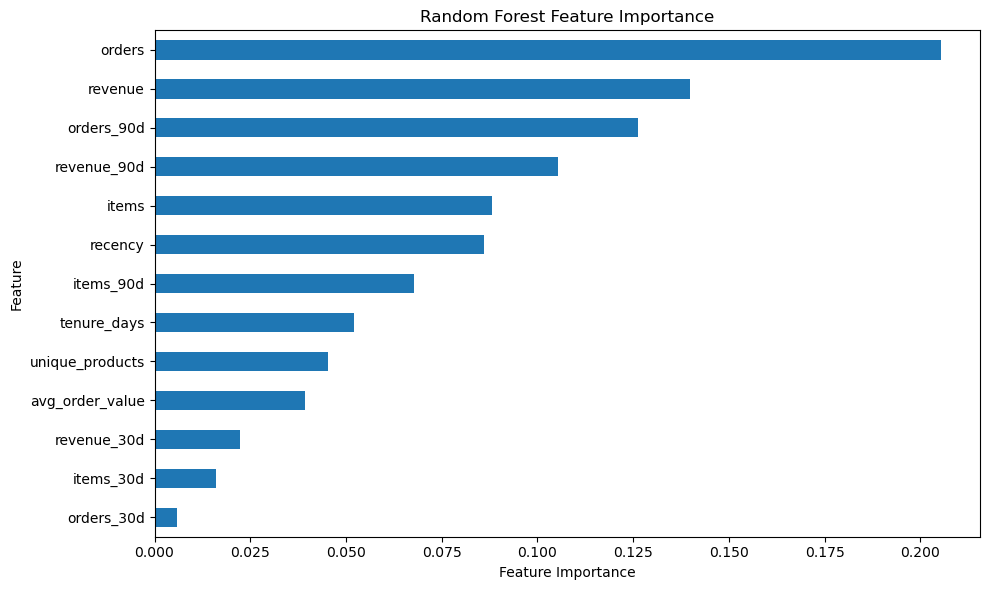

In [125]:
import matplotlib.pyplot as plt

importance.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [126]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_recent,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

perm_importance

,feature,importance_mean,importance_std
4,recency,0.025217,0.001549
0,orders,0.016254,0.001566
1,revenue,0.011153,0.001002
3,unique_products,0.006166,0.000461
5,tenure_days,0.003932,0.000239
10,orders_90d,0.002787,0.000421
2,items,0.002750,0.000422
11,revenue_90d,0.002282,0.000317
6,avg_order_value,0.001672,0.000243
12,items_90d,0.001291,0.000426


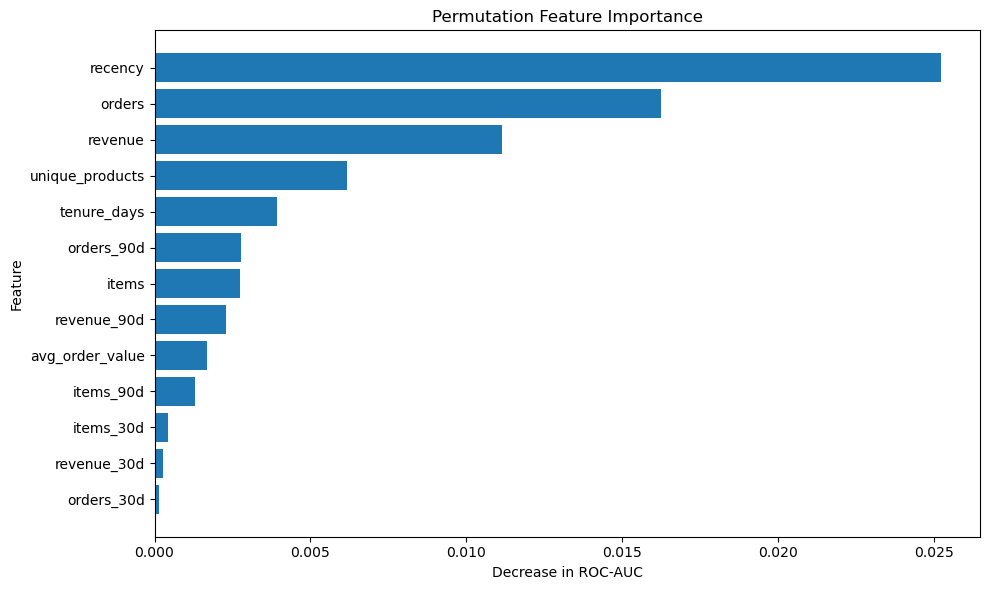

In [127]:
import matplotlib.pyplot as plt

plot_data = perm_importance.sort_values("importance_mean")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["feature"],
    plot_data["importance_mean"]
)

plt.xlabel("Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

Permutation importance identified recency as the most influential feature on the held-out test set, followed by order frequency and historical revenue.

### HistogradientBoosting

In [128]:
%%time
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

gb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification report:")
print(classification_report(y_test, y_pred_gb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Accuracy: 0.7943631542767358

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.46      0.56      5793
           1       0.81      0.93      0.87     14573

    accuracy                           0.79     20366
   macro avg       0.76      0.69      0.71     20366
weighted avg       0.78      0.79      0.78     20366

ROC-AUC: 0.8139133081546431
CPU times: total: 6.06 s
Wall time: 3.86 s


In [129]:
train = model_data[
    model_data["prediction_date"] < "2011-03-01"
].copy()

validation = model_data[
    (model_data["prediction_date"] >= "2011-03-01") &
    (model_data["prediction_date"] < "2011-06-01")
].copy()

test = model_data[
    model_data["prediction_date"] >= "2011-06-01"
].copy()

In [130]:
feature_cols = [
    "orders",
    "revenue",
    "items",
    "unique_products",
    "recency",
    "tenure_days",
    "avg_order_value",
    "orders_30d",
    "revenue_30d",
    "items_30d",
    "orders_90d",
    "revenue_90d",
    "items_90d"
]

X_train = train[feature_cols]
y_train = train["churn_next_60d"]

X_val = validation[feature_cols]
y_val = validation["churn_next_60d"]

X_test = test[feature_cols]
y_test = test["churn_next_60d"]

In [131]:
X_train.shape, X_val.shape, X_test.shape

((32682, 13), (14075, 13), (20366, 13))

In [132]:
print("Train:", train["prediction_date"].min(), "→", train["prediction_date"].max())
print("Validation:", validation["prediction_date"].min(), "→", validation["prediction_date"].max())
print("Test:", test["prediction_date"].min(), "→", test["prediction_date"].max())

Train: 2010-06-01 00:00:00 → 2011-02-01 00:00:00
Validation: 2011-03-01 00:00:00 → 2011-05-01 00:00:00
Test: 2011-06-01 00:00:00 → 2011-09-01 00:00:00


# Model Comparison

Several models were evaluated using the same feature set and chronological data split.

| Model | ROC-AUC | Accuracy | Purpose |
|---|---:|---:|---|
| Dummy Classifier | — | 0.716 | Baseline |
| Logistic Regression | 0.804 | 0.782 | Linear baseline |
| Random Forest | 0.815 | 0.794 | Nonlinear model |
| HistGradientBoosting | 0.814 | 0.794 | Boosting benchmark |

Logistic Regression provides a useful linear baseline, while the tree-based models capture nonlinear relationships between customer behavior and future inactivity.

Random Forest was used as the final model because it provided competitive predictive performance and straightforward feature-importance analysis.

# Final model

In [133]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [134]:
y_prob_val = rf_final.predict_proba(X_val)[:, 1]

# Model evaluation

In [135]:
%%time
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:

    y_pred_val = (
        y_prob_val >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred_val),
        "recall": recall_score(y_val, y_pred_val),
        "f1": f1_score(y_val, y_pred_val)
    })

val_threshold_results = pd.DataFrame(results)

val_threshold_results

CPU times: total: 172 ms
Wall time: 181 ms


,threshold,precision,recall,f1
0,0.10,0.729180,0.999605,0.843242
1,0.15,0.735497,0.998814,0.847166
2,0.20,0.742149,0.997430,0.851058
3,0.25,0.751120,0.993971,0.855648
4,0.30,0.760076,0.989819,0.859866
5,0.35,0.767918,0.982801,0.862172
6,0.40,0.777541,0.972521,0.864169
7,0.45,0.791953,0.957201,0.866771
8,0.50,0.809401,0.931007,0.865956
9,0.55,0.823759,0.895819,0.858279


In [136]:
X_train_final = pd.concat(
    [X_train, X_val],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_val],
    ignore_index=True
)

print(X_train_final.shape)
print(y_train_final.shape)

(46757, 13)
(46757,)


In [137]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
y_prob_test = rf_final.predict_proba(X_test)[:, 1]

In [139]:
best_threshold = 0.45

y_pred_test = (
    y_prob_test >= best_threshold
).astype(int)

In [140]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_test))

print("\nClassification report:")
print(classification_report(y_test, y_pred_test))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))

Accuracy: 0.7937739369537464

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.41      0.53      5793
           1       0.80      0.95      0.87     14573

    accuracy                           0.79     20366
   macro avg       0.78      0.68      0.70     20366
weighted avg       0.79      0.79      0.77     20366

ROC-AUC: 0.8145717787230438


The final Random Forest achieved ROC-AUC of 0.815 and 95% recall for customers with no purchase during the following 60 days, using a threshold selected on a chronological validation period.

In [141]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_test)
cm

array([[ 2383,  3410],
       [  790, 13783]])

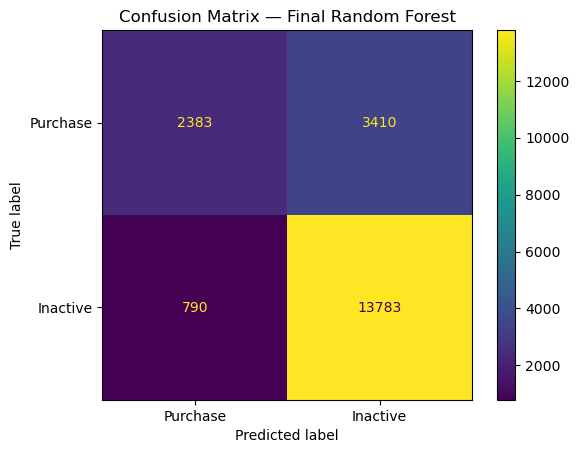

In [142]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Purchase", "Inactive"]
).plot()

plt.title("Confusion Matrix — Final Random Forest")
plt.show()

In [143]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 2383
False Positives: 3410
False Negatives: 790
True Positives: 13783


In [144]:
flagged = (y_prob_test >= 0.45).sum()
total = len(y_test)

print("Flagged customers:", flagged)
print("Total customers:", total)
print("Flagged percentage:", flagged / total)

Flagged customers: 17193
Total customers: 20366
Flagged percentage: 0.8442011195129137


# Top-K Targeting

In [145]:
import pandas as pd
import numpy as np

results = []

# Sort customers from highest predicted inactivity probability
ranked = pd.DataFrame({
    "probability": y_prob_test,
    "actual": y_test.values
}).sort_values(
    "probability",
    ascending=False
).reset_index(drop=True)

for pct in [0.10, 0.20, 0.30, 0.40, 0.50]:

    n = int(len(ranked) * pct)

    top_k = ranked.iloc[:n]

    precision = top_k["actual"].mean()

    results.append({
        "top_percent": pct * 100,
        "customers_targeted": n,
        "precision": precision
    })

top_k_results = pd.DataFrame(results)

top_k_results

,top_percent,customers_targeted,precision
0,10.0,2036,0.963654
1,20.0,4073,0.944267
2,30.0,6109,0.927811
3,40.0,8146,0.914314
4,50.0,10183,0.897083


The model ranked customers by predicted 60-day purchase inactivity. Among the highest-risk 10% of customers, 96.4% subsequently made no purchase during the next 60 days. Expanding the campaign to the top 30% still produced 92.8% precision. These are retrospective ranking results on the held-out test period and do not imply that contacting these customers would prevent inactivity.

# Lift analysis

In [146]:
# Lift analyses
baseline_rate = y_test.mean()

results = []

total_positive = y_test.sum()

for pct in [0.10, 0.20, 0.30, 0.40, 0.50]:

    n = int(len(ranked) * pct)

    top_k = ranked.iloc[:n]

    positives = top_k["actual"].sum()
    precision = top_k["actual"].mean()

    lift = precision / baseline_rate
    capture_rate = positives / total_positive

    results.append({
        "top_percent": pct * 100,
        "customers_targeted": n,
        "precision": precision,
        "lift": lift,
        "capture_rate": capture_rate
    })

lift_df = pd.DataFrame(results)

lift_df

,top_percent,customers_targeted,precision,lift,capture_rate
0,10.0,2036,0.963654,1.346722,0.134633
1,20.0,4073,0.944267,1.319628,0.263913
2,30.0,6109,0.927811,1.296631,0.388938
3,40.0,8146,0.914314,1.277768,0.511082
4,50.0,10183,0.897083,1.253688,0.626844


The top 10% of customers ranked by predicted inactivity has 1.35× the concentration of inactive customers compared with random targeting.

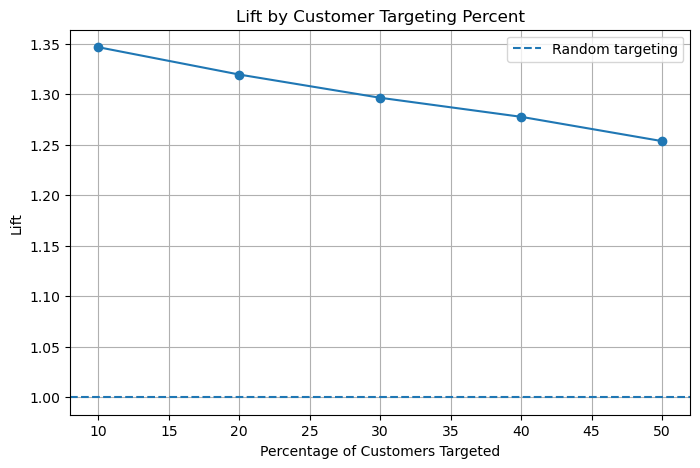

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    lift_df["top_percent"],
    lift_df["lift"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random targeting"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Lift")
plt.title("Lift by Customer Targeting Percent")
plt.legend()
plt.grid(True)

plt.show()

# Cumulative gains

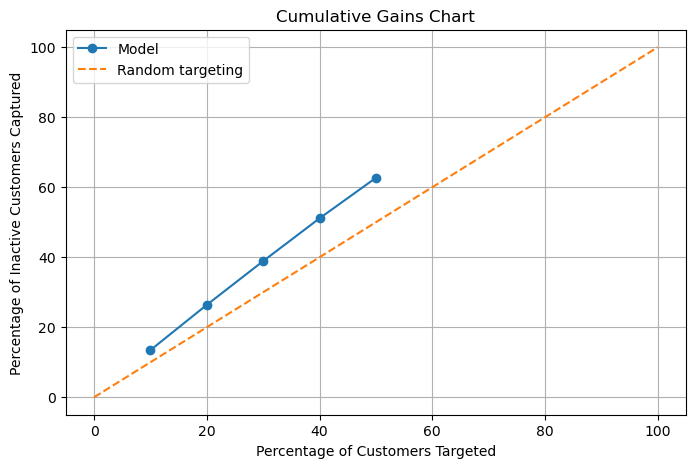

In [148]:
# cumulative gains chart

plt.figure(figsize=(8, 5))

plt.plot(
    lift_df["top_percent"],
    lift_df["capture_rate"] * 100,
    marker="o",
    label="Model"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random targeting"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Percentage of Inactive Customers Captured")
plt.title("Cumulative Gains Chart")
plt.legend()
plt.grid(True)

plt.show()

# Business recommendations

1. Prioritize high-risk customers: Use predicted 60-day inactivity probabilities to rank customers and focus retention efforts on those with the highest predicted risk.

2. Allocate campaign capacity using model rankings: The top 10% achieved 96.4% precision and 1.35× lift, while the top 30% captured 38.9% of all inactive customers. Campaign size can therefore be adjusted according to available resources.

3. Monitor recency: Recency was the strongest feature according to permutation importance, making it a useful early-warning signal for declining customer activity.

4. Combine risk with customer value: Since 21+ order customers represented 45.6% of revenue while accounting for only 5.1% of customers, retention prioritization should consider both predicted inactivity risk and customer value.

5. Validate interventions experimentally: The model predicts inactivity risk but does not establish that retention campaigns cause customers to return. Controlled experiments should be used to measure incremental retention and revenue.

# Limitations 

1. Short-term inactivity is used as a proxy for churn
The target defines churn as making no purchase during the 60 days following the prediction date. This represents short-term inactivity rather than permanent customer churn.

2. The model identifies risk, not causality
The model predicts which customers are more likely to become inactive, but it does not determine whether a retention campaign would cause them to return. Retention strategies should be evaluated using controlled experiments such as A/B tests.

3. Historical dataset
The model is trained on historical transaction data from a single retailer. Customer behavior and business conditions may change over time, so performance should be monitored when applied to new data.

4. Limited customer information
The dataset contains transaction-level information but does not include potentially useful factors such as marketing interactions, customer demographics, website activity, complaints, or reasons for leaving.

5. Class imbalance
The target is imbalanced, with approximately 67% of customers classified as having no purchase in the next 60 days. Therefore, accuracy alone is not sufficient for evaluating the model. ROC-AUC, precision/recall, Top-K precision, and lift are also considered.

6. Retention capacity is not modeled directly
The model ranks customers by predicted risk, but the optimal number of customers to contact depends on campaign budget, available staff, customer value, and the cost and expected benefit of each intervention.

# Conclusion 

RetentionLab developed an end-to-end customer retention analytics workflow using transactional e-commerce data. Point-in-time feature engineering was used to ensure that customer features were based only on information available at each prediction date, preventing future information from entering the model.

The final Random Forest achieved a ROC-AUC of 0.815 on the held-out test period. Recency, order frequency, and historical revenue were among the most informative behavioral signals for predicting whether a customer would make no purchase during the following 60 days.

The model can also support practical campaign prioritization. Customers in the top 10% of predicted inactivity risk had 96.4% precision, while the top 30% captured 38.9% of customers who subsequently became inactive.

These results suggest that predictive ranking can help a retention team allocate limited campaign capacity. However, the model identifies risk rather than the causal effect of an intervention. Future work should test retention strategies through controlled experiments and measure their incremental impact on purchases and revenue.